# Solver convergence comparison

In [1]:
import json
import math
import os
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import HTML, display

RESULTS_DIR = Path("results")
PROBLEM_METADATA_PATH = Path("problem_metadata.json")

# The result files to compare, by default every file in results/. Each is
# labeled by the "name" recorded in it. Edit to pick a subset.
EXPERIMENTS = sorted(RESULTS_DIR.glob("*.json"))

# Categorical colors, assigned to experiments in EXPERIMENTS order.
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
           "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
GRID_COLOR = "#e3e3e0"
REFERENCE_COLOR = "#8a8a86"

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#b8b8b4",
    "axes.grid": True,
    "grid.color": GRID_COLOR,
    "grid.linewidth": 0.8,
    "legend.frameon": False,
})

## Load

In [2]:
def load_experiment(path):
    with open(path) as f:
        data = json.load(f)
    by_problem = {}
    for entry in data["results"]:
        lbs = [ev["lb"] for ev in entry["events"] if ev["type"] == "lb"]
        ubs = [ev["ub"] for ev in entry["events"] if ev["type"] == "ub"]
        key = os.path.abspath(entry["path"])
        by_problem[key] = {
            **entry,
            "final_lb": max(lbs) if lbs else None,
            "final_ub": min(ubs) if ubs else None,
            # When the run's bounds stopped changing: at convergence, or at
            # the time limit.
            "t_end": entry.get("converge_t", entry["time_limit"]),
        }
    return {"label": data["name"], "description": data["description"],
            "dir": os.path.abspath(data["dir"]), "path": path, "by_problem": by_problem}


if not EXPERIMENTS:
    raise ValueError(f"no result files under {RESULTS_DIR.resolve()}")
if len(EXPERIMENTS) > len(PALETTE):
    raise ValueError(f"at most {len(PALETTE)} experiments can be compared at once")

experiments = [load_experiment(path) for path in EXPERIMENTS]
labels = [exp["label"] for exp in experiments]
if len(set(labels)) < len(labels):
    raise ValueError(f"experiment names are not unique: {labels}")
colors = {exp["label"]: PALETTE[i] for i, exp in enumerate(experiments)}

with open(PROBLEM_METADATA_PATH) as f:
    problem_metadata = json.load(f)


def reference_ub(problem_key):
    """Best-known upper bound (tour seconds) for the problem, or None."""
    return problem_metadata["problems"].get(problem_key, {}).get("ub")


def dataset_name(dir_key):
    return problem_metadata["datasets"][dir_key]["name"]


datasets = sorted({exp["dir"] for exp in experiments})

# Every problem any experiment measured, in iteration order, with the
# number of required groups each one has.
problems = {}
for exp in experiments:
    for key, entry in exp["by_problem"].items():
        problems[key] = (entry["iteration"], entry["num_required_groups"])
problems = dict(sorted(problems.items(), key=lambda kv: (kv[1][0], kv[0])))

for exp in experiments:
    n_conv = sum("converge_t" in e for e in exp["by_problem"].values())
    print(f"{exp['label']} on {dataset_name(exp['dir'])}: "
          f"{len(exp['by_problem'])} problems, {n_conv} converged"
          + (f" - {exp['description']}" if exp["description"] else ""))

2opt-baseline on munich-bahn-baseline-202609: 27 problems, 10 converged
bnb-slack-and-timetravel on munich-bahn-baseline-202609: 14 problems, 3 converged
bnb-baseline on munich-bahn-baseline-202609: 27 problems, 3 converged
hk-baseline on munich-bahn-baseline-202609: 10 problems, 10 converged


## Summary table

In [3]:
def format_seconds(seconds):
    return f"{seconds:.2f} s" if seconds < 10 else f"{seconds:.0f} s"


def gap_percent(value, ref):
    return (value - ref) / ref * 100


def summarize(entry, ref):
    if "error" in entry:
        return "error"
    if "converge_t" in entry:
        return format_seconds(entry["converge_t"])
    parts = []
    if ref is not None:
        if entry["final_ub"] is not None:
            parts.append(f"ub +{gap_percent(entry['final_ub'], ref):.1f}%")
        if entry["final_lb"] is not None:
            parts.append(f"lb {gap_percent(entry['final_lb'], ref):.1f}%")
    if not parts:
        parts.append("no bounds")
    return "not converged (" + ", ".join(parts) + ")"


header = "".join(f"<th>{exp['label']}</th>" for exp in experiments)
rows = []
for key, (iteration, groups) in problems.items():
    ref = reference_ub(key)
    cells_html = "".join(
        f"<td>{summarize(exp['by_problem'][key], ref) if key in exp['by_problem'] else ''}</td>"
        for exp in experiments
    )
    best = "" if ref is None else f"{ref // 3600:d}:{ref % 3600 // 60:02d}:{ref % 60:02d}"
    rows.append(f"<tr><td>{iteration}</td><td>{groups}</td><td>{best}</td>{cells_html}</tr>")
display(HTML(
    "<table><thead><tr><th>iteration</th><th>groups</th><th>best known</th>"
    + header + "</tr></thead><tbody>" + "".join(rows) + "</tbody></table>"
))

iteration,groups,best known,2opt-baseline,bnb-slack-and-timetravel,bnb-baseline,hk-baseline
0,15,2:55:50,0.02 s,57 s,64 s,0.17 s
1,16,3:04:20,0.07 s,120 s,109 s,0.33 s
2,17,3:07:50,0.03 s,261 s,267 s,0.76 s
3,18,3:09:50,0.05 s,"not converged (ub +0.0%, lb -0.5%)","not converged (ub +0.0%, lb -0.5%)",1.39 s
4,19,3:15:50,0.04 s,"not converged (ub +0.0%, lb -3.6%)","not converged (ub +0.0%, lb -3.3%)",2.70 s
5,20,3:18:50,1.21 s,"not converged (ub +0.5%, lb -5.0%)","not converged (ub +0.5%, lb -4.8%)",6.16 s
6,21,3:21:40,0.19 s,"not converged (ub +0.5%, lb -6.4%)","not converged (ub +0.5%, lb -5.2%)",16 s
7,22,3:22:40,6.37 s,"not converged (ub +0.3%, lb -6.3%)","not converged (ub +0.0%, lb -5.6%)",32 s
8,23,3:22:50,2.31 s,"not converged (ub +0.2%, lb -6.4%)","not converged (ub +0.2%, lb -5.8%)",65 s
9,24,3:25:50,0.06 s,"not converged (ub +0.0%, lb -6.4%)","not converged (ub +0.0%, lb -5.8%)",156 s


## Time to converge vs problem size

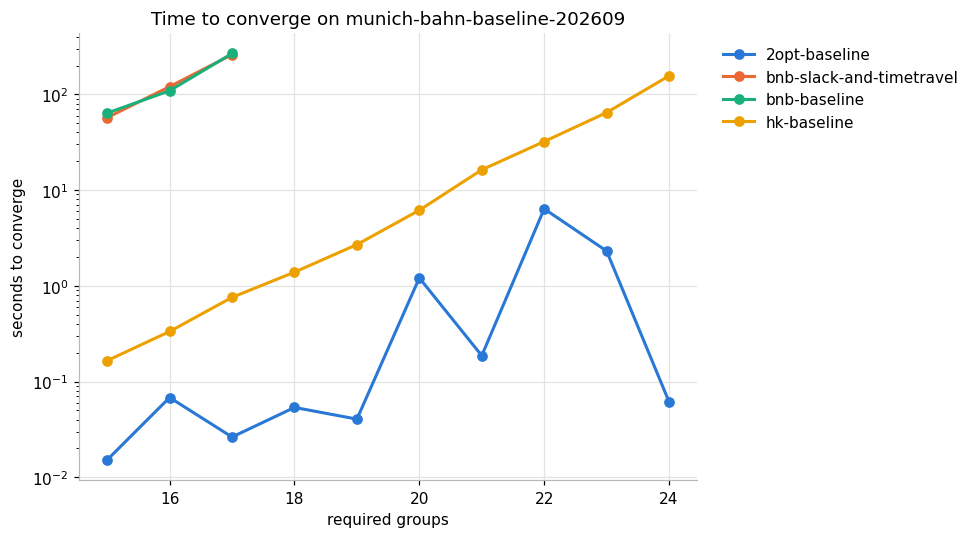

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
for exp in experiments:
    converged = sorted((e for e in exp["by_problem"].values() if "converge_t" in e),
                       key=lambda e: (e["num_required_groups"], e["iteration"]))
    if converged:
        ax.plot([e["num_required_groups"] for e in converged],
                [e["converge_t"] for e in converged],
                color=colors[exp["label"]], lw=2, marker="o", ms=6, label=exp["label"])

ax.set_yscale("log")
ax.set_xlabel("required groups")
ax.set_ylabel("seconds to converge")
ax.set_title("Time to converge on " + ", ".join(dataset_name(d) for d in datasets))
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
fig.tight_layout()
plt.show()

## Bound trajectories per problem

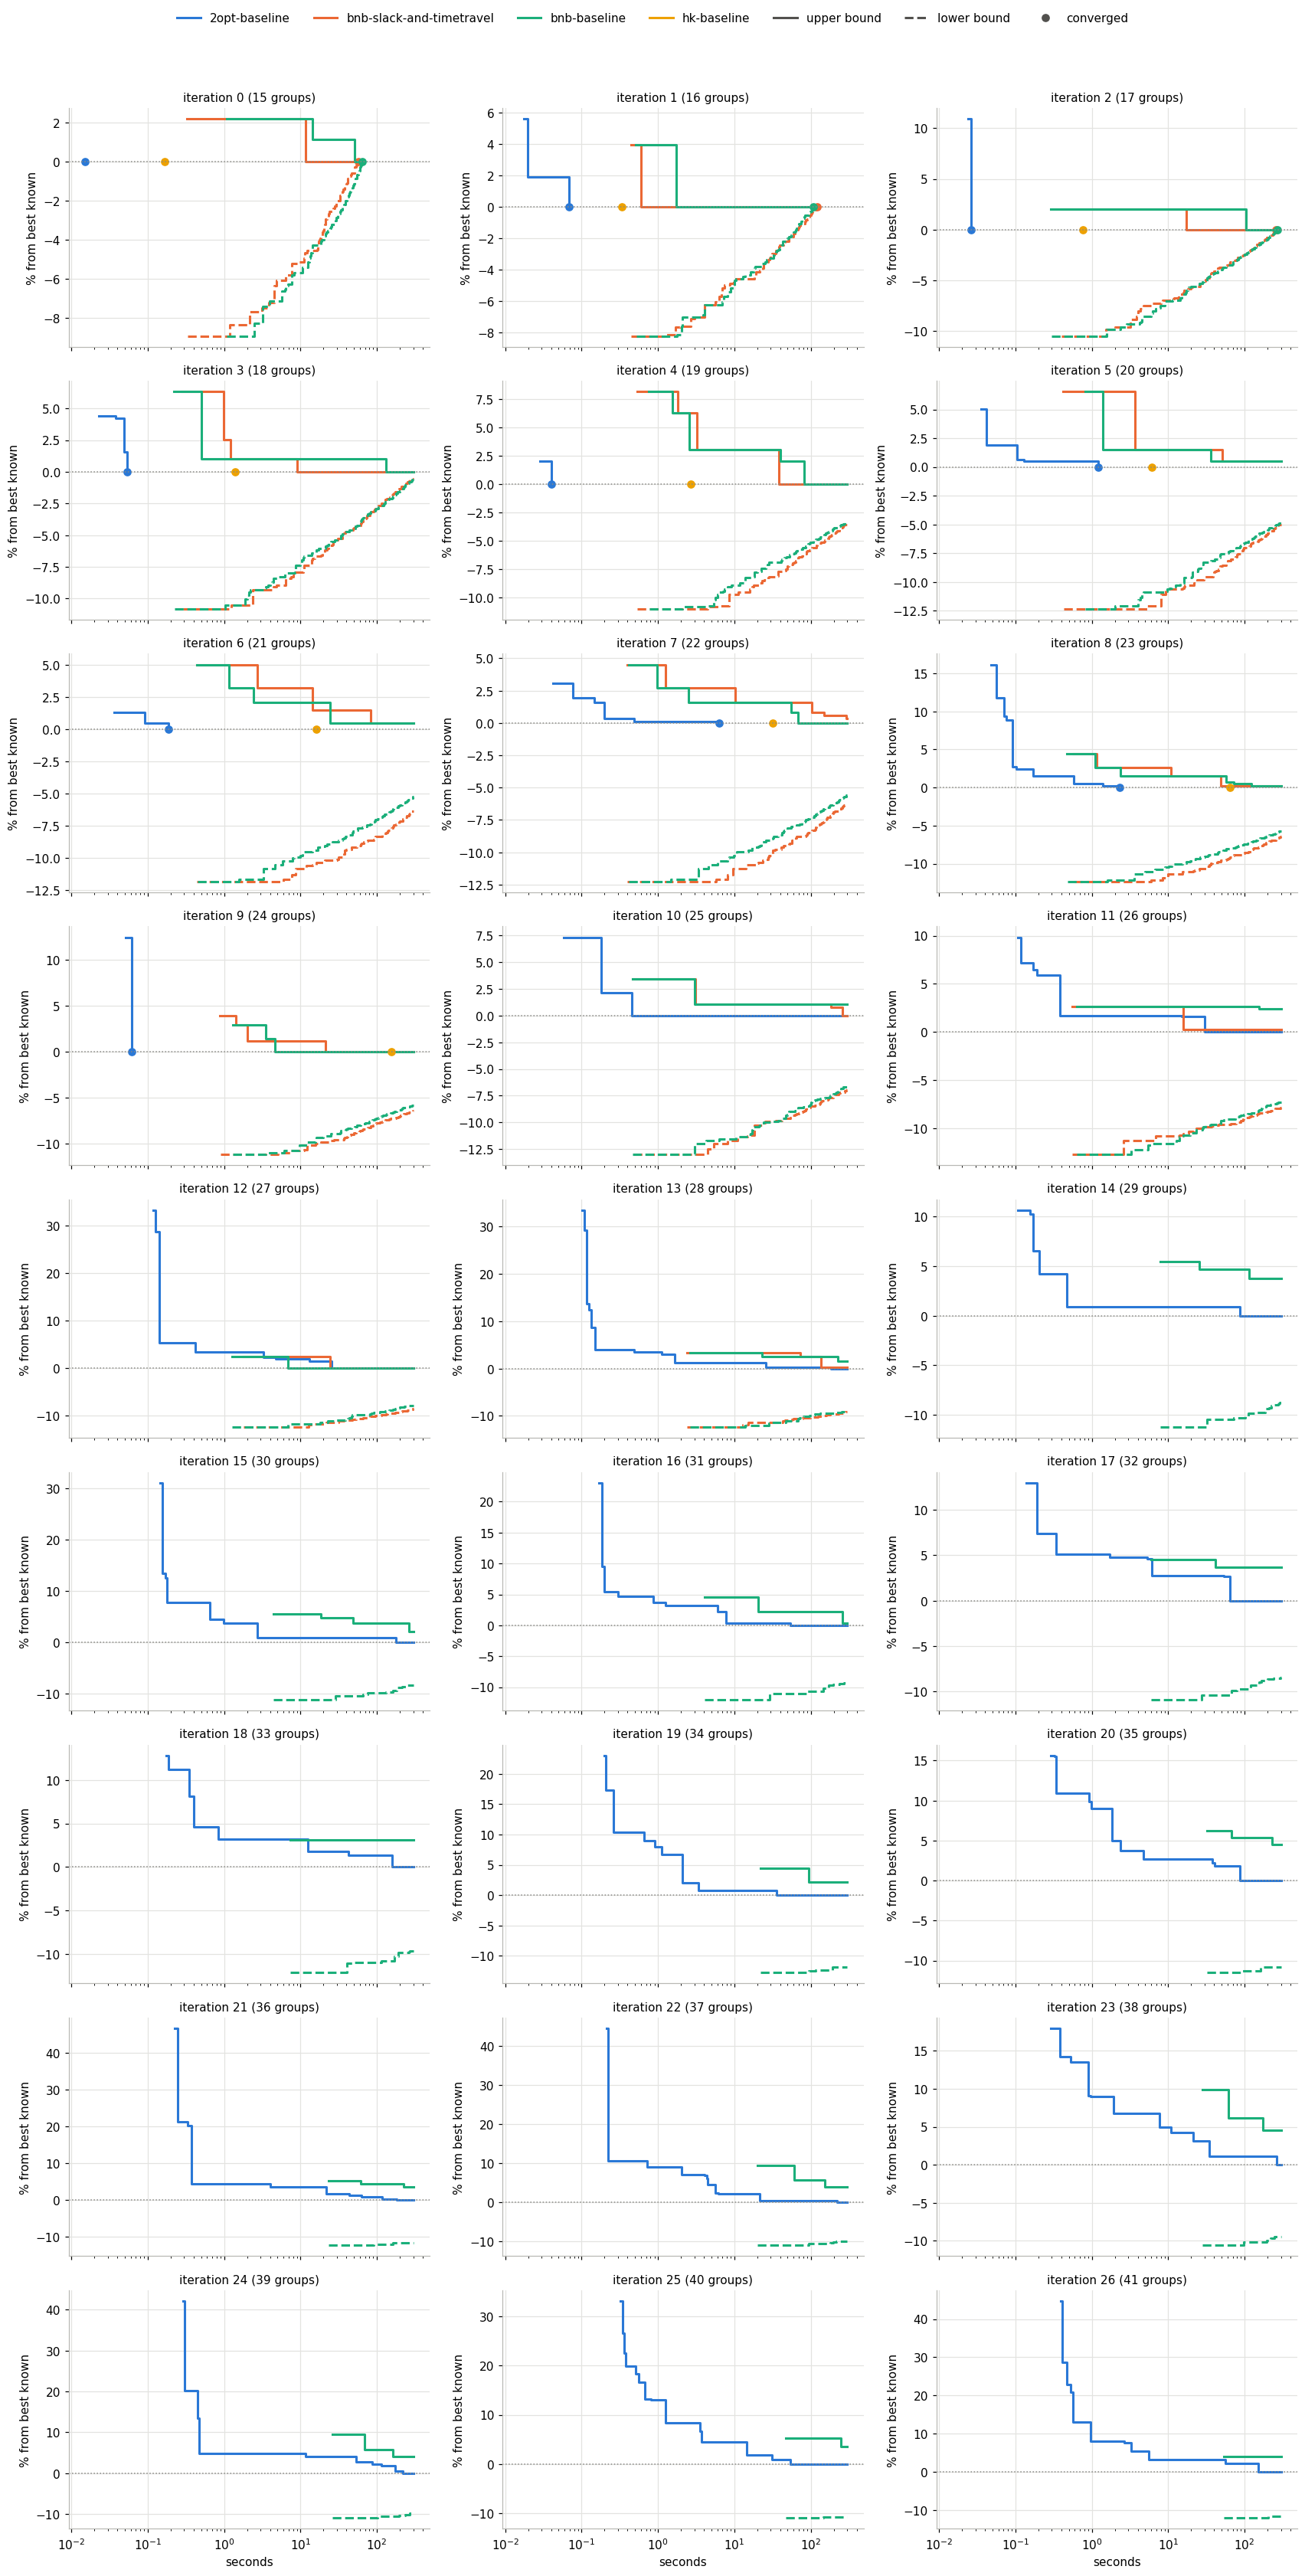

In [5]:
def trajectory(entry, kind, ref):
    """(times, values) of a bound's step function, extended to the run's end."""
    events = [(ev["t"], ev[kind]) for ev in entry["events"] if ev["type"] == kind]
    if not events:
        return [], []
    scale = (lambda v: gap_percent(v, ref)) if ref is not None else (lambda v: v / 60)
    times = [max(t, 1e-3) for t, _ in events] + [max(entry["t_end"], events[-1][0], 1e-3)]
    values = [scale(v) for _, v in events] + [scale(events[-1][1])]
    return times, values


ncols = 3
nrows = math.ceil(len(problems) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.4 * nrows),
                         sharex=True, squeeze=False)
for ax, (key, (iteration, groups)) in zip(axes.flat, problems.items()):
    ref = reference_ub(key)
    for exp in experiments:
        entry = exp["by_problem"].get(key)
        if entry is None:
            continue
        color = colors[exp["label"]]
        for kind, style in (("ub", "-"), ("lb", "--")):
            times, values = trajectory(entry, kind, ref)
            if times:
                ax.step(times, values, where="post", color=color, ls=style, lw=2)
        if "converge_t" in entry and entry["final_ub"] is not None:
            y = gap_percent(entry["final_ub"], ref) if ref is not None else entry["final_ub"] / 60
            ax.plot([max(entry["converge_t"], 1e-3)], [y], marker="o", ms=6, color=color)
    if ref is not None:
        ax.axhline(0, color=REFERENCE_COLOR, lw=1, ls=":")
        ax.set_ylabel("% from best known")
    else:
        ax.set_ylabel("tour duration (min)")
    ax.set_xscale("log")
    title = f"iteration {iteration} ({groups} groups)"
    if len(datasets) > 1:
        title = f"{dataset_name(os.path.dirname(key))}, {title}"
    ax.set_title(title, fontsize=10)
for ax in axes.flat[len(problems):]:
    ax.set_visible(False)
for ax in axes[-1]:
    ax.set_xlabel("seconds")

handles = [Line2D([], [], color=colors[exp["label"]], lw=2, label=exp["label"])
           for exp in experiments]
handles += [Line2D([], [], color="#52514e", lw=2, ls="-", label="upper bound"),
            Line2D([], [], color="#52514e", lw=2, ls="--", label="lower bound"),
            Line2D([], [], color="#52514e", marker="o", ls="", label="converged")]
fig.legend(handles=handles, loc="upper center", ncol=len(handles),
           bbox_to_anchor=(0.5, 1.0))
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()